# MovieLens-1M Dataset Exploration

This notebook explores the MovieLens-1M dataset before preprocessing.

Objectives:

- Understand the dataset structure
- Compute descriptive statistics
- Measure dataset sparsity
- Examine rating distributions
- Explore user and item interaction distributions
- Determine the effect of converting explicit ratings into implicit feedback

The results from this notebook will guide preprocessing and later be used in the dissertation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Better plot appearance
plt.style.use("ggplot")

# Display wider tables
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "movielens"

ratings_path = DATA_PATH / "ratings.dat"
movies_path = DATA_PATH / "movies.dat"
users_path = DATA_PATH / "users.dat"

In [4]:
ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    movies_path,
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movie_id", "title", "genres"]
)

users = pd.read_csv(
    users_path,
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

In [5]:
print("Ratings")
display(ratings.head())

print("Movies")
display(movies.head())

print("Users")
display(users.head())

Ratings


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Movies


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


Users


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [6]:
ratings.info()

movies.info()

users.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  3883 non-null   int64
 1   title     3883 non-null   str  
 2   genres    3883 non-null   str  
dtypes: int64(1), str(2)
memory usage: 91.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     6040 non-null   int64
 1   gender      6040 non-null   str  
 2   age         6040 non-null   int64
 3 

In [7]:
# Missing-value checks
print("Missing values in ratings:")
display(ratings.isna().sum())

print("Missing values in movies:")
display(movies.isna().sum())

print("Missing values in users:")
display(users.isna().sum())

# Exact duplicate rows
print(f"Duplicate rating rows: {ratings.duplicated().sum():,}")

# Duplicate user-item interactions
duplicate_user_items = ratings.duplicated(
    subset=["user_id", "movie_id"],
    keep=False
)

print(
    f"Rows involved in duplicate user-item interactions: "
    f"{duplicate_user_items.sum():,}"
)

Missing values in ratings:


user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Missing values in movies:


movie_id    0
title       0
genres      0
dtype: int64

Missing values in users:


user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64

Duplicate rating rows: 0
Rows involved in duplicate user-item interactions: 0


In [8]:
num_users = ratings["user_id"].nunique()
num_movies = ratings["movie_id"].nunique()
num_interactions = len(ratings)

print(f"Users: {num_users:,}")
print(f"Movies: {num_movies:,}")
print(f"Interactions: {num_interactions:,}")

Users: 6,040
Movies: 3,706
Interactions: 1,000,209


In [9]:
density = num_interactions / (num_users * num_movies)
sparsity = 1 - density

print(f"Density : {density:.6f}")
print(f"Sparsity: {sparsity:.6f}")

Density : 0.044684
Sparsity: 0.955316


In [10]:
user_counts = ratings.groupby("user_id").size()

print(user_counts.describe())

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64


In [11]:
print(f"Mean interactions/user   : {user_counts.mean():.2f}")
print(f"Median interactions/user : {user_counts.median():.2f}")
print(f"Minimum                 : {user_counts.min()}")
print(f"Maximum                 : {user_counts.max()}")

Mean interactions/user   : 165.60
Median interactions/user : 96.00
Minimum                 : 20
Maximum                 : 2314


In [12]:
movie_counts = ratings.groupby("movie_id").size()

print(movie_counts.describe())

print(f"Mean interactions/movie   : {movie_counts.mean():.2f}")
print(f"Median interactions/movie : {movie_counts.median():.2f}")
print(f"Minimum                  : {movie_counts.min()}")
print(f"Maximum                  : {movie_counts.max()}")

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64
Mean interactions/movie   : 269.89
Median interactions/movie : 123.50
Minimum                  : 1
Maximum                  : 3428


In [13]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

print("Earliest interaction:")
print(ratings["datetime"].min())

print()

print("Latest interaction:")
print(ratings["datetime"].max())

Earliest interaction:
2000-04-25 23:05:32

Latest interaction:
2003-02-28 17:49:50


In [14]:
ratings["rating"].value_counts().sort_index()

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

In [15]:
positive = ratings[ratings["rating"] >= 4]
negative = ratings[ratings["rating"] < 4]

print("Positive interactions")
print(len(positive))

print()

print("Removed interactions")
print(len(negative))

print()

print(f"Retention: {100 * len(positive) / len(ratings):.2f}%")

Positive interactions
575281

Removed interactions
424928

Retention: 57.52%


In [16]:
positive_users = positive["user_id"].nunique()
positive_movies = positive["movie_id"].nunique()
positive_interactions = len(positive)

positive_density = positive_interactions / (
    positive_users * positive_movies
)
positive_sparsity = 1 - positive_density

positive_user_counts = positive.groupby("user_id").size()
positive_movie_counts = positive.groupby("movie_id").size()

print("After implicit-feedback conversion")
print("----------------------------------")
print(f"Users: {positive_users:,}")
print(f"Movies: {positive_movies:,}")
print(f"Interactions: {positive_interactions:,}")
print(f"Density: {positive_density:.6f}")
print(f"Sparsity: {positive_sparsity:.6f}")

print(
    f"Users with fewer than 5 positive interactions: "
    f"{(positive_user_counts < 5).sum():,}"
)

print(
    f"Movies with fewer than 5 positive interactions: "
    f"{(positive_movie_counts < 5).sum():,}"
)

After implicit-feedback conversion
----------------------------------
Users: 6,038
Movies: 3,533
Interactions: 575,281
Density: 0.026968
Sparsity: 0.973032
Users with fewer than 5 positive interactions: 4
Movies with fewer than 5 positive interactions: 408


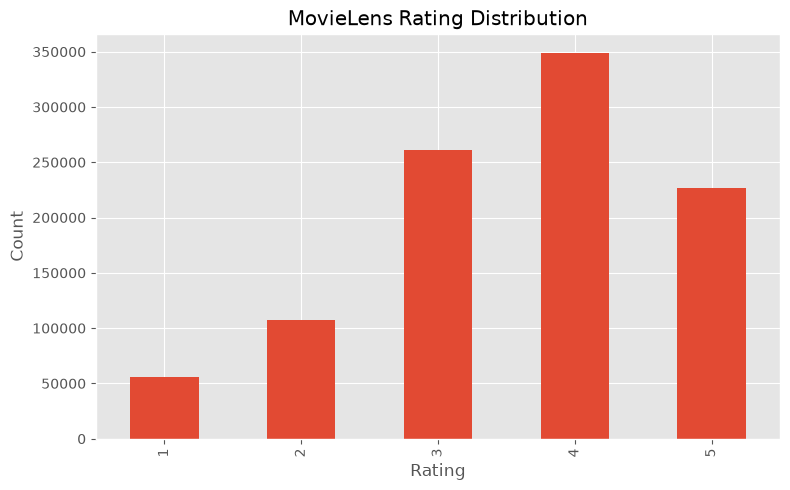

In [17]:
plt.figure(figsize=(8,5))

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("MovieLens Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

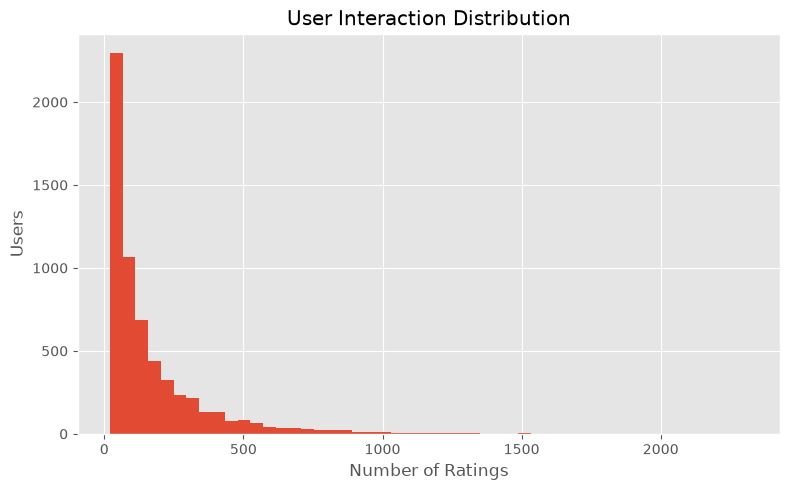

In [18]:
plt.figure(figsize=(8,5))

plt.hist(user_counts, bins=50)

plt.title("User Interaction Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")

plt.tight_layout()

plt.show()

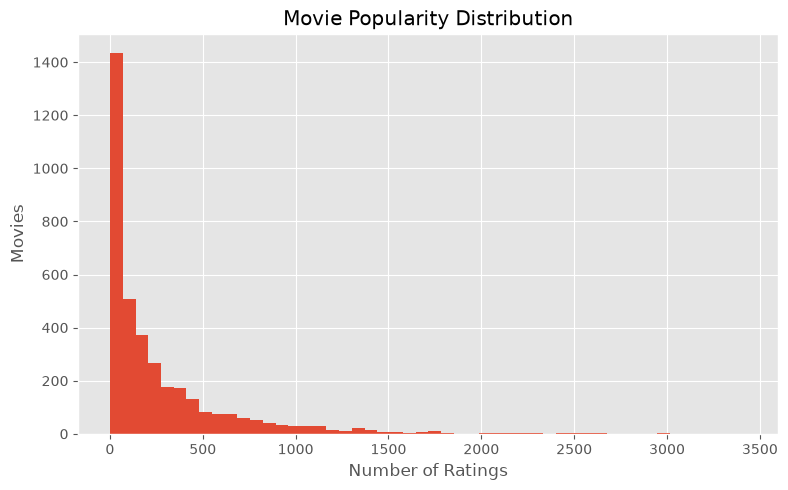

In [19]:
plt.figure(figsize=(8,5))

plt.hist(movie_counts, bins=50)

plt.title("Movie Popularity Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Movies")

plt.tight_layout()

plt.show()

In [20]:
FIGURES = PROJECT_ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Rating distribution
fig, ax = plt.subplots(figsize=(8, 5))

ratings["rating"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax
)

ax.set_title("MovieLens-1M Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Ratings")

fig.tight_layout()
fig.savefig(
    FIGURES / "movielens_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

# User interaction distribution
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(user_counts, bins=50)

ax.set_title("MovieLens-1M User Interaction Distribution")
ax.set_xlabel("Number of Ratings per User")
ax.set_ylabel("Number of Users")

fig.tight_layout()
fig.savefig(
    FIGURES / "movielens_user_interactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

# Movie popularity distribution
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(movie_counts, bins=50)

ax.set_title("MovieLens-1M Movie Popularity Distribution")
ax.set_xlabel("Number of Ratings per Movie")
ax.set_ylabel("Number of Movies")

fig.tight_layout()
fig.savefig(
    FIGURES / "movielens_movie_popularity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print(f"Figures saved to: {FIGURES.resolve()}")

Figures saved to: C:\Research Project\recommender-sparsity-honours\results\figures


In [21]:
summary = pd.DataFrame({
    "Statistic": [
        "Raw users",
        "Raw movies with ratings",
        "Raw interactions",
        "Raw density",
        "Raw sparsity",
        "Positive interactions",
        "Positive users",
        "Positive movies",
        "Interactions retained"
    ],
    "Value": [
        f"{num_users:,}",
        f"{num_movies:,}",
        f"{num_interactions:,}",
        f"{density:.6f}",
        f"{sparsity:.6f}",
        f"{positive_interactions:,}",
        f"{positive_users:,}",
        f"{positive_movies:,}",
        f"{100 * positive_interactions / num_interactions:.2f}%"
    ]
})

display(summary)

,Statistic,Value
0,Raw users,"6,040"
1,Raw movies with ratings,"3,706"
2,Raw interactions,"1,000,209"
3,Raw density,0.044684
4,Raw sparsity,0.955316
5,Positive interactions,"575,281"
6,Positive users,"6,038"
7,Positive movies,"3,533"
8,Interactions retained,57.52%


## Initial observations

- The raw dataset contains 6,040 users, 3,706 rated movies, and 1,000,209 ratings.
- The interaction matrix is approximately 95.53% sparse.
- Retaining ratings of 4 or 5 produces 575,281 positive interactions, corresponding to 57.52% of the raw ratings.
- User activity and movie popularity are strongly uneven, with a small number of users and movies receiving substantially more interactions than most others.
- Iterative 5-core filtering will be applied after implicit-feedback conversion to ensure that all retained users and items have sufficient interaction histories.